# Retail Store Sales Data Analysis Project

## Phase 1: Data loading and Pre-processing

### Background of the Study
Retail businesses generate large volumes of sales data on a daily basis. This data often contains missing values and duplicate records, which makes analysis challenging. Analyzing such data helps businesses understand sales patterns and improve decision-making.

### Aim of the Project
The aim of this project is to analyze retail store sales data using exploratory data analysis techniques in order to identify sales patterns and trends.

### Problem Definition
Retail sales data is often messy and contains missing values and duplicate records. The challenge is to clean and analyze this data to extract meaningful insights.

### Dataset Description
The dataset used in this project contains 12,575 rows and 11 columns related to retail sales transactions. The dataset includes missing and duplicate values, making it suitable for data cleaning and analysis.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("retail_store_sales.csv")

## Phase 2: Dataset Overview and Context

The Retail Store Sales dataset contains transactional data collected from a retail business. 
It includes information related to customer purchases, product categories, item details, pricing, quantities sold, payment methods, store locations, discounts applied, and transaction dates.

The dataset consists of multiple records representing individual sales transactions. 
Since the data reflects real-world retail operations, it contains data quality issues such as missing values and inconsistencies, which makes it suitable for demonstrating data cleaning and exploratory data analysis techniques.

Analyzing this dataset helps in understanding customer purchasing behavior, identifying high-performing product categories, evaluating the impact of discounts, and observing sales trends across different locations and time periods.


### 2.1 First Look at the Data

We will examinate the first 20 rows of the dataset to understand.
The df.head() function displays the first 5 rows by default giving a quick preview of the dataset.We can use the df.head(n) method to top n rows of the dataframe,where is an integer.

In [9]:
df.head(20)

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False
5,TXN_7482416,CUST_09,Patisserie,NaN,NaN,10.0,200.0,Credit Card,Online,2023-11-30,NaN
6,TXN_3652209,CUST_07,Food,Item_1_FOOD,5.0,8.0,40.0,Credit Card,In-store,2023-06-10,True
7,TXN_1372952,CUST_21,Furniture,NaN,33.5,NaN,NaN,Digital Wallet,In-store,2024-04-02,True
8,TXN_9728486,CUST_23,Furniture,Item_16_FUR,27.5,1.0,27.5,Credit Card,In-store,2023-04-26,False
9,TXN_2722661,CUST_25,Butchers,Item_22_BUT,36.5,3.0,109.5,Cash,Online,2024-03-14,False


In [5]:
df.shape

(12575, 11)

**Observation:**  
The dataset contains 12,575 rows and 11 columns.

### 2.2 Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              11362 non-null  object 
 4   Price Per Unit    11966 non-null  float64
 5   Quantity          11971 non-null  float64
 6   Total Spent       11971 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  8376 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


#### This shows:

**a.Column names**

**b.Data types**

**c.Missing values**


### 2.3 Checking Missing Values

In [8]:
df.isnull().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

**Observation:**  
The dataset contains missing values in multiple columns, indicating that data cleaning is required.

### 2.4 Checking Duplicate Records

In [12]:
df.duplicated().sum()

np.int64(0)

**Observation:**  
No duplicate records were found in the dataset. However, missing values are present and will be handled during preprocessing.


### 2.5 Missing Value Analysis

Before performing any analysis, it is important to check for missing values in the dataset. 
Missing values can negatively impact the accuracy of analysis and visualizations.


In [14]:
df.isnull().sum()


Transaction ID         0
Customer ID            0
Category               0
Item                1213
Price Per Unit       609
Quantity             604
Total Spent          604
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    4199
dtype: int64

**Observation:**  
The dataset contains missing values in multiple columns. These missing values need to be handled before further analysis.


### 2.6 Missing Value Handling Strategy

To handle missing values:
- Numerical columns are filled using the **mean** value.
- Categorical columns are filled using the **mode** value.

This approach ensures that the dataset remains consistent without removing important records.


In [15]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [13]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())


In [15]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

### 2.7 Data Type Inspection

Data types define how values in each column are interpreted and processed during analysis. 
Before performing any calculations or visualizations, it is essential to verify that all columns have appropriate data types. 
Incorrect data types can lead to inaccurate results, especially when performing numerical operations or time-based analysis.



In [20]:
df.dtypes

Transaction ID       object
Customer ID          object
Category             object
Item                 object
Price Per Unit      float64
Quantity            float64
Total Spent         float64
Payment Method       object
Location             object
Transaction Date     object
Discount Applied       bool
dtype: object

### 2.8 Transaction Date Conversion

The Transaction Date column represents the date on which each sales transaction occurred.
Converting this column into datetime format allows time-based analysis such as identifying sales trends over time.


In [23]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')

**Observation:**  
The Transaction Date column has been successfully converted into datetime format.


### 2.9 (a) Feature Verification: Total Spent

The dataset already contains a column named Total Spent, which represents the total amount spent per transaction.
This feature is verified to ensure consistency with Price Per Unit and Quantity.


In [24]:
df[['Price Per Unit', 'Quantity', 'Total Spent']].head()

,Price Per Unit,Quantity,Total Spent
0,18.5,10.0,185.0
1,29.0,9.0,261.0
2,21.5,2.0,43.0
3,27.5,9.0,247.5
4,12.5,7.0,87.5


### 2.9 (b) Feature Engineering: Discounted Amount

To enhance the analysis, a new feature called Discounted_Amount is created.
This feature represents the final amount paid after applying discounts.


In [26]:
df['Discounted_Amount'] = df['Total Spent'] - (df['Total Spent'] * df['Discount Applied'] / 100)

**Final Observation:**  
The dataset has been enhanced by verifying existing features and creating a new feature for discounted amount, improving the depth of analysis.


## Phase 2 Analysis Summary 

- The project began with an introduction to the retail store sales dataset, outlining the project aim, problem definition, and relevance of analyzing real-world retail data.

- The dataset was successfully loaded and explored to understand its structure, containing 12,575 rows and 11 columns related to retail transactions.

- An initial data quality assessment was performed, which revealed the presence of missing values, confirming the dataset was not clean and required preprocessing.

- Missing values were handled using appropriate imputation techniques, where numerical columns were filled using mean values and categorical columns were filled using mode values.

- The dataset was examined for duplicate records, and no duplicate entries were found in the current version of the data.

- Data types of all columns were inspected to ensure correctness, and the transaction date column was converted into datetime format to enable time-based analysis.

- Existing features such as total spending per transaction were verified for consistency, and an additional feature representing discounted amount was created to enhance analytical depth.

- By the end of Phase 1, the dataset was cleaned, structured, and enriched, making it fully prepared for exploratory data analysis and insight generation.


## Phase 3: Importance of Exploratory Data Analysis (EDA) 

Exploratory Data Analysis (EDA) plays a crucial role in this retail store sales project as it helps in understanding customer purchasing behavior and overall sales performance. Through EDA, patterns, trends, and relationships within the sales data can be identified using visual and statistical methods.

EDA allows the identification of high-performing product categories, popular items, preferred payment methods, and location-based sales variations. It also helps in evaluating the impact of discounts and purchase quantities on total spending. By performing EDA, the dataset is transformed from raw numbers into meaningful insights that support better business decision-making.


### EDA Process 1: Summary Statistics Analysis

In this step, summary statistics are used to understand the central tendency and spread of numerical features in the retail dataset. 
This provides insights into average spending, quantity purchased, and pricing variations across transactions.


In [11]:
df.describe()

,Price Per Unit,Quantity,Total Spent
count,11966.000000,11971.000000,11971.000000
mean,23.365912,5.536380,129.652577
std,10.743519,2.857883,94.750697
min,5.000000,1.000000,5.000000
25%,14.000000,3.000000,51.000000
50%,23.000000,6.000000,108.500000
75%,33.500000,8.000000,192.000000
max,41.000000,10.000000,410.000000


In [16]:
df.isnull().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

### A. Univariate Analysis

Univariate analysis focuses on analyzing a single variable at a time. 
The objective is to understand the distribution, frequency, and patterns of individual features in the dataset without considering relationships with other variables.


#### A1. Distribution of Total Spending

This analysis examines how the total amount spent varies across all transactions. 
It helps in identifying common spending ranges and extreme values.


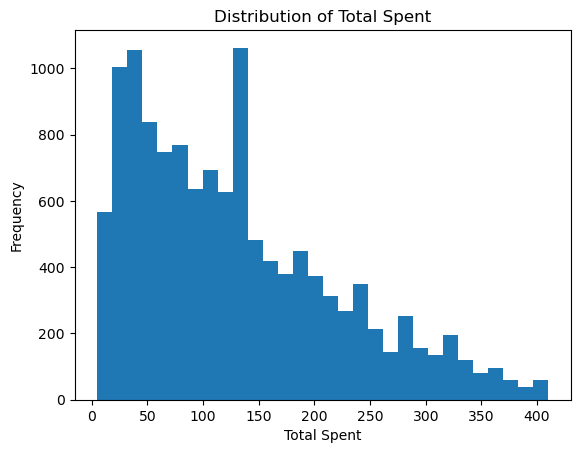

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['Total Spent'], bins=30)
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

**Observation:**
Most transactions fall within a moderate spending range, while fewer transactions show very high spending.


#### A2. Quantity Purchased Distribution

This analysis shows how many units are typically purchased per transaction.


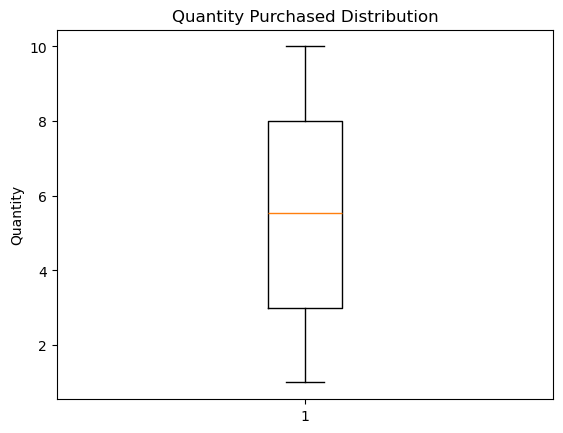

In [36]:
plt.figure()
plt.boxplot(df['Quantity'])
plt.title('Quantity Purchased Distribution')
plt.ylabel('Quantity')
plt.show()

**Observation:**
Most purchases involve a small number of items, with a few transactions involving higher quantities.

#### A3. Payment Method Analysis

This analysis shows the frequency of different payment methods used by customers.


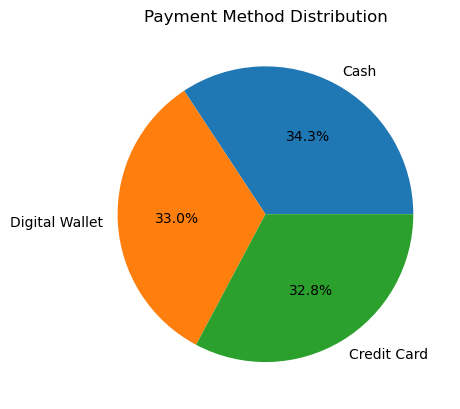

In [38]:
payment_counts = df['Payment Method'].value_counts()

plt.figure()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
plt.title('Payment Method Distribution')
plt.show()

**Observation:**
Certain payment methods are more popular, indicating customer preference for specific modes of payment.

### B. Bivariate Analysis

Bivariate analysis examines the relationship between two variables. 
It helps in understanding how one variable influences or is related to another.

#### B1. Category-wise Total Spending

This analysis compares total sales across different product categories to identify high-performing categories.


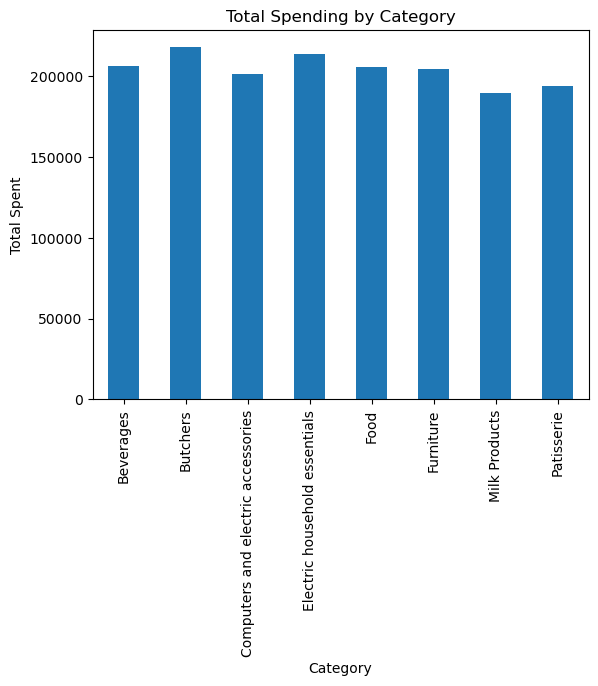

In [40]:
category_sales = df.groupby('Category')['Total Spent'].sum()

plt.figure()
category_sales.plot(kind='bar')
plt.title('Total Spending by Category')
plt.xlabel('Category')
plt.ylabel('Total Spent')
plt.show()

**Observation:**
Some categories generate significantly higher sales, indicating stronger customer demand.

#### B2. Relationship Between Quantity and Total Spending

This analysis examines whether higher quantities lead to higher total spending.


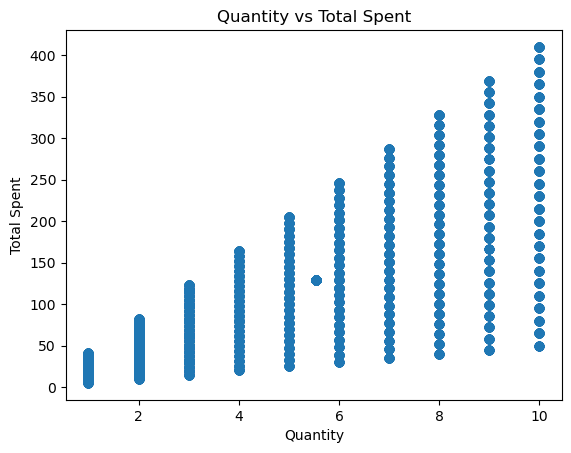

In [42]:
plt.figure()
plt.scatter(df['Quantity'], df['Total Spent'])
plt.title('Quantity vs Total Spent')
plt.xlabel('Quantity')
plt.ylabel('Total Spent')
plt.show()

**Observation:**
An increase in quantity generally leads to higher total spending, though variations exist.

#### B3. Impact of Discounts on Spending

This analysis studies how discounts affect the total amount spent by customers.


<Figure size 640x480 with 0 Axes>

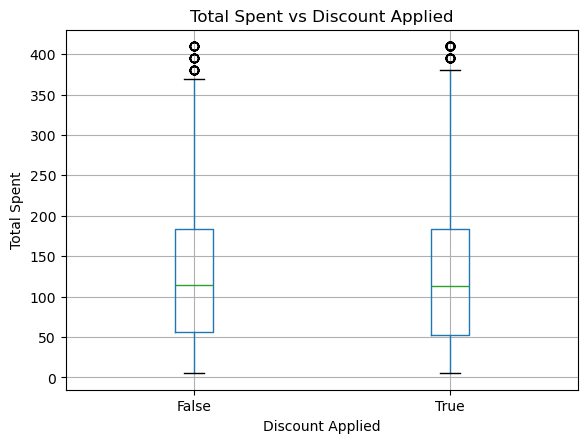

In [44]:
plt.figure()
df.boxplot(column='Total Spent', by='Discount Applied')
plt.title('Total Spent vs Discount Applied')
plt.suptitle('')
plt.xlabel('Discount Applied')
plt.ylabel('Total Spent')
plt.show()

**Observation:**
Transactions with discounts often show higher spending, suggesting discounts encourage larger purchases.

#### B4. Location-wise Sales Comparison

This analysis compares sales performance across different store locations.


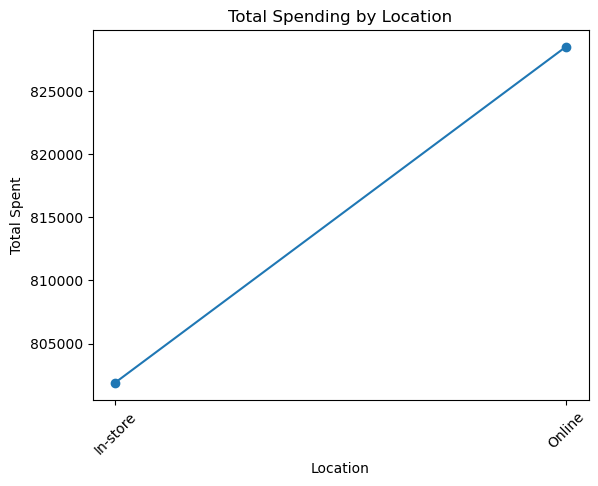

In [62]:
location_sales = df.groupby('Location')['Total Spent'].sum()

plt.figure()
plt.plot(location_sales.index, location_sales.values, marker='o')
plt.title('Total Spending by Location')
plt.xlabel('Location')
plt.ylabel('Total Spent')
plt.xticks(rotation=45)
plt.show()

**Observation:**
Some locations perform better than others, indicating variation in regional sales performance.


### C. Multivariate Analysis

Multivariate analysis involves examining more than two variables at the same time to understand complex relationships within the dataset. 
It helps in identifying how multiple features interact with each other and influence overall sales performance.

#### C1. Correlation Analysis of Numerical Variables

This analysis uses a correlation heatmap to understand the relationship between numerical features such as price per unit, quantity, total spent, and discount applied. 
It helps identify which variables move together and influence sales.


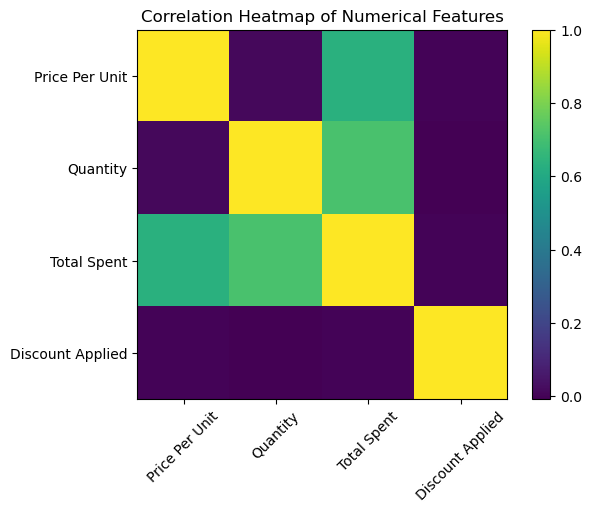

In [9]:
import matplotlib.pyplot as plt

numerical_cols = ['Price Per Unit', 'Quantity', 'Total Spent', 'Discount Applied']
corr_matrix = df[numerical_cols].corr()

plt.figure()
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(numerical_cols)), numerical_cols, rotation=45)
plt.yticks(range(len(numerical_cols)), numerical_cols)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Observation:**
Total spent shows a strong relationship with quantity and price per unit, indicating that these variables directly affect customer spending.

#### C2. Impact of Discount on Product Sales Across Categories

This multivariate analysis examines how discounts influence total spending across different product categories. 
It helps determine whether discounts increase sales performance within specific categories.

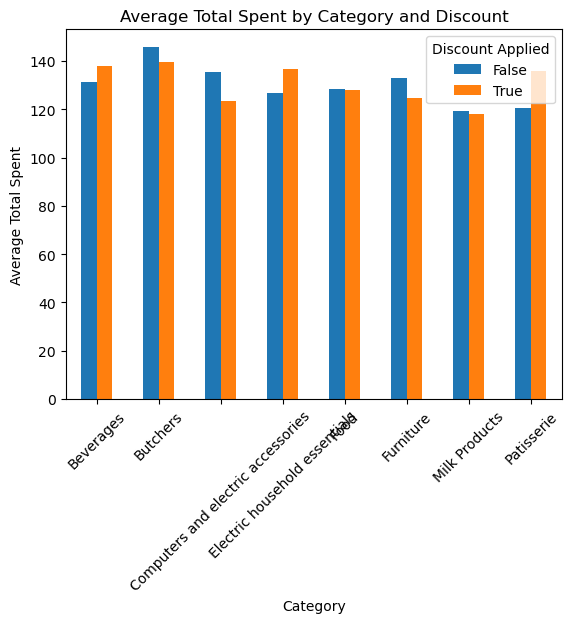

In [8]:
discount_category_sales = (
    df.groupby(['Category', 'Discount Applied'])['Total Spent']
      .mean()
      .unstack()
)

discount_category_sales.plot(kind='bar')
plt.title('Average Total Spent by Category and Discount')
plt.xlabel('Category')
plt.ylabel('Average Total Spent')
plt.xticks(rotation=45)
plt.show()

**Observation:**
In most categories, transactions with discounts show higher average spending compared to transactions without discounts. 
This suggests that discounts positively influence customer purchasing behavior.

#### C3. Sales Analysis by Category and Location

This multivariate analysis examines how total spending varies across different product categories and store locations simultaneously. 
It helps identify which category performs better in specific locations.

In [68]:
category_location_sales = pd.pivot_table(
    df,
    values='Total Spent',
    index='Category',
    columns='Location',
    aggfunc='mean'
)

category_location_sales

Location,In-store,Online
Category,,
Beverages,131.658324,131.587472
Butchers,136.597903,140.765599
Computers and electric accessories,126.705297,131.252123
Electric household essentials,133.037951,135.326185
Food,127.508508,131.073178
Furniture,129.057541,127.188477
Milk Products,118.999691,120.036037
Patisserie,127.637065,125.555382


**Observation:**
Average spending varies across categories and locations, indicating that customer preferences differ based on product type and store location.

#### C4. Combined Analysis of Price, Category, and Total Spending

This multivariate analysis studies how price per unit and product category together influence total spending. 
It helps identify whether higher-priced items in specific categories contribute more to overall revenue.


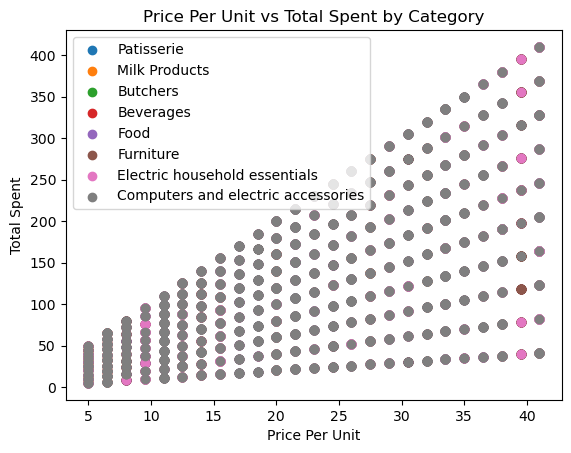

In [6]:
plt.figure()

for category in df['Category'].unique():
    subset = df[df['Category'] == category]
    plt.scatter(subset['Price Per Unit'], subset['Total Spent'], label=category)

plt.title('Price Per Unit vs Total Spent by Category')
plt.xlabel('Price Per Unit')
plt.ylabel('Total Spent')
plt.legend()
plt.show()

**Observation:**
Higher-priced items generally result in higher total spending, especially within certain product categories. 
This indicates that category and pricing together influence overall sales performance.

## Phase 3 Analysis Summary 

In Phase 5, exploratory data analysis was performed on the cleaned retail store sales dataset to extract meaningful insights and understand customer purchasing behavior.

Univariate analysis was conducted to study individual features such as total spending, quantity purchased, and payment methods. These analyses helped in understanding the distribution, frequency, and variation of key variables across transactions.

Bivariate analysis was used to examine relationships between two variables, including category-wise sales performance, the relationship between quantity and total spending, and the impact of discounts on customer purchases. These analyses provided insights into how different factors influence sales outcomes.

Multivariate analysis was further applied to explore the combined effect of multiple variables. A correlation heatmap was used to analyze relationships among numerical features such as price per unit, quantity, total spent, and discounts. Additionally, scatter plot analysis was performed to study how price per unit and quantity together influence total spending.

Overall, the exploratory data analysis phase helped transform the processed dataset into actionable insights, enabling a better understanding of sales patterns, customer preferences, and key factors affecting retail performance.

## Phase 4: Conclusion 

The retail store sales analysis successfully examined customer purchasing behavior and overall sales performance using exploratory data analysis techniques.

The analysis identified high-performing product categories, evaluated the impact of discounts on customer spending, and compared sales performance across different locations. It was observed that total spending is strongly influenced by price per unit and quantity purchased. Additionally, discounts were found to positively affect average spending in several product categories.

Payment method analysis revealed customer preferences, while location-based analysis highlighted regional performance differences. These insights can support better business decisions related to pricing strategies, discount planning, inventory management, and regional sales optimization.

Overall, the project demonstrates how data-driven analysis can help retail businesses improve sales performance and understand customer behavior more effectively.

## Key Insights

- Total spending is primarily influenced by price per unit and quantity purchased.
- Discounts positively impact customer spending in multiple product categories.
- Certain product categories contribute significantly more to overall revenue.
- Sales performance varies across locations, indicating regional demand differences.
- Customers show clear preferences in payment methods.

## Limitations

- The analysis is based only on historical transactional data.
- External factors such as seasonality and market trends were not considered.
- Predictive modeling was not included in this project.

## Future Improvements

1. Sales Forecasting:
   Machine learning models can be developed to predict future sales trends based on historical transaction data.

2. Customer Segmentation:
   Customers can be grouped based on purchasing behavior to design targeted marketing and promotional strategies.

3. Discount Optimization:
   Advanced analysis can be performed to determine the optimal discount percentage that maximizes revenue without reducing profit margins.

4. Interactive Dashboard Development:
   An interactive dashboard using tools like Power BI or Tableau can be created to enable real-time monitoring of key business metrics.

## Business Recommendations

- Focus inventory planning on high-performing product categories.
- Use targeted discounts in categories where they significantly increase spending.
- Improve marketing strategies in lower-performing locations.
- Optimize pricing strategies based on customer purchasing patterns.
- Enhance support for popular payment methods to improve customer experience.


## References

- Python Documentation – https://www.python.org/
- Pandas Documentation – https://pandas.pydata.org/
- Matplotlib Documentation – https://matplotlib.org/
- Kaggle – Retail Store Sales Dataset
- McKinney, W. (2022). Python for Data Analysis.
